# Feedforward Pointcloud Reconstruction

This tutorial runs **VGGT-X** and **MapAnything** on keyframes extracted from a real video, then compares the resulting pointclouds side by side. Both models run feedforward inference (no optimisation loop) and write results to zarr caches that downstream notebooks — `semantic_lifting`, `localization`, and `bundle_adjustment` — depend on. **Run this notebook before any of those.**

**Prerequisite:** [Keyframe Extraction](../01_preprocessing/keyframe_extraction.ipynb) must have been executed first to populate the `images/` directory used here.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import open3d as o3d
import pyvista as pv
import torch
%matplotlib inline

pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

from collab_splats.pointcloud.feedforward import VGGTXCreator, MapAnythingCreator
from collab_splats.pointcloud.feedforward.base import FeedforwardResult
from collab_splats.pointcloud.utils import clean_pointcloud
from collab_splats.utils.visualization import pointcloud_to_polydata, visualize_splat, create_camera_frustum_pyvista

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
VIDEO_PATH = "/workspace/fieldwork-data/birds/2024-02-06/SplatsSD/C0043.MP4"
DATASET    = "birds_c0043"

CACHE  = Path("../../.cache") / DATASET
IMAGES = CACHE / "images"

assert IMAGES.exists() and any(IMAGES.glob("*.jpg")), (
    f"No images found in {IMAGES}. Run 01_preprocessing/keyframe_extraction first."
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}  |  images: {len(list(IMAGES.glob('*.jpg')))}")

device: cuda  |  images: 80


## §1 — VGGT-X Reconstruction

Loads a cached VGGT-X reconstruction from zarr if available, skipping GPU inference (~3–5 min on GPU). If no cache exists, runs VGGT-X on the keyframes and saves the result. The zarr file is chunked by frame for efficient per-frame random access by downstream notebooks (semantic_lifting, localization).

In [4]:
_vggtx_cache = CACHE / "vggtx" / "reconstruction.zarr"
_vggtx_cache.parent.mkdir(parents=True, exist_ok=True)

if _vggtx_cache.exists():
    result_vggt = FeedforwardResult.load_zarr(_vggtx_cache)
    print(f"Loaded VGGT-X result from cache  ({result_vggt.pts3d.shape[0]:,} pts)")
else:
    creator_vggt = VGGTXCreator()
    creator_vggt.load_model(device=device)
    creator_vggt.setup_inference(IMAGES)
    creator_vggt.run_inference()
    creator_vggt.postprocess()
    result_vggt = creator_vggt.outputs
    result_vggt.save_zarr(_vggtx_cache)
    print(f"VGGT-X done  →  saved to {_vggtx_cache}")

Loaded VGGT-X result from cache  (500,000 pts)


## §2 — VGGT-X Post-processing and Visualisation

Removes statistical outliers and downsamples via voxel grid to produce a clean pointcloud. Confidence statistics are printed to help diagnose prediction quality.

In [5]:
# Clean via Open3D statistical outlier removal + voxel downsampling
_pcd = o3d.geometry.PointCloud()
_pcd.points = o3d.utility.Vector3dVector(result_vggt.pts3d)
_pcd.colors = o3d.utility.Vector3dVector(result_vggt.colors.astype(np.float64) / 255.0)
_cleaned, _ = clean_pointcloud(_pcd)

pts3d_vggt = np.asarray(_cleaned.points, dtype=np.float32)
colors_vggt = (np.asarray(_cleaned.colors) * 255).astype(np.uint8)

conf_vggt_mean = result_vggt.conf.cpu().float().mean().item() if result_vggt.conf is not None else float("nan")
conf_vggt_std  = result_vggt.conf.cpu().float().std().item()  if result_vggt.conf is not None else float("nan")

print(f"Points: {len(result_vggt.pts3d):,} raw → {len(pts3d_vggt):,} filtered")
print(f"Conf:   mean={conf_vggt_mean:.3f}  std={conf_vggt_std:.3f}")

Points: 500,000 raw → 187,484 filtered
Conf:   mean=nan  std=nan


## §3 — VGGT-X Pointcloud Viewer

Renders the filtered VGGT-X pointcloud with camera frustums overlaid. Blue frustums show predicted camera poses.

2026-05-23 07:39:39.261 (  22.101s) [    7AEECD7F7740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


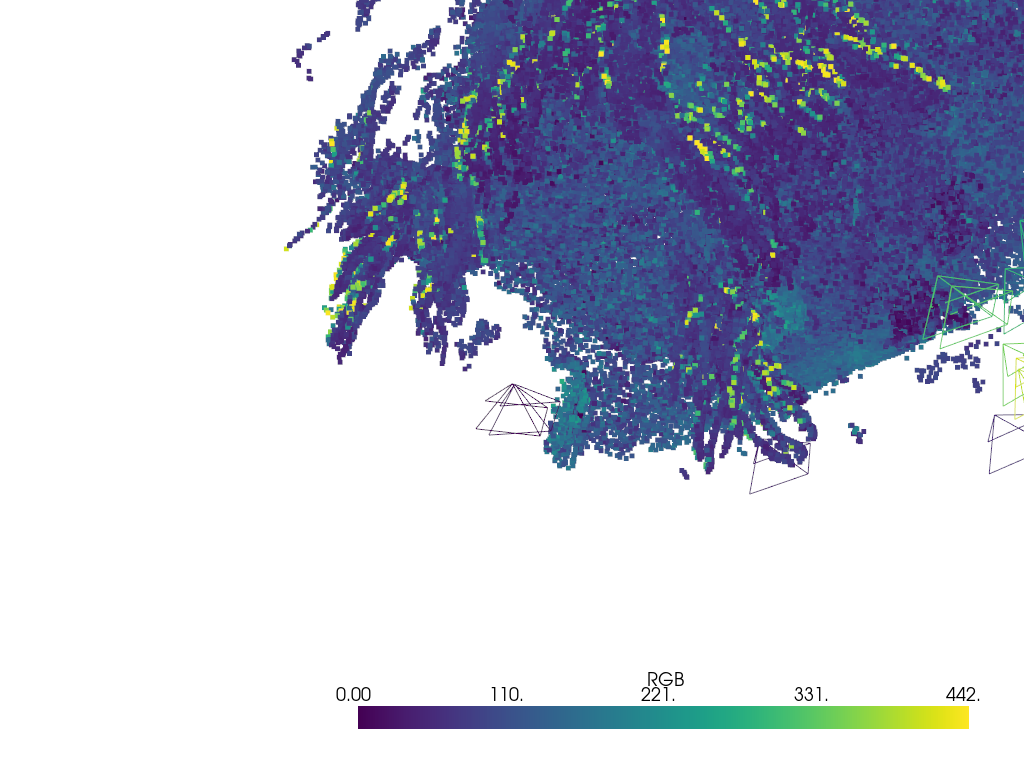

In [6]:
cloud_vggt = pointcloud_to_polydata(pts3d_vggt, RGB=colors_vggt)
c2w_vggt = [np.linalg.inv(ext) for ext in result_vggt.extrinsics]
pl = visualize_splat(cloud_vggt, aligned_cameras=c2w_vggt)
pl.show()

## §4 — MapAnything Reconstruction

MapAnything predicts dense depth and camera poses via cross-view consistency.
Uses `confidence_percentile` to mask unreliable pixels before unprojection.

In [7]:
_ma_cache = CACHE / "mapanything" / "reconstruction.zarr"
_ma_cache.parent.mkdir(parents=True, exist_ok=True)

if _ma_cache.exists():
    result_ma = FeedforwardResult.load_zarr(_ma_cache)
    print(f"Loaded MapAnything result from cache  ({result_ma.pts3d.shape[0]:,} pts)")
else:
    creator_ma = MapAnythingCreator()
    creator_ma.load_model(device=device)
    creator_ma.setup_inference(IMAGES)
    creator_ma.run_inference()
    creator_ma.postprocess()
    result_ma = creator_ma.outputs
    result_ma.save_zarr(_ma_cache)
    print(f"MapAnything done  →  saved to {_ma_cache}")

[07:39:40] Loading model (cuda)...                                                                      ]8;id=2701757;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=2701758;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#541\541]8;;\

Loading pretrained dinov2_vitg14 from torch hub


Using cache found in /workspace/models/hub/facebookresearch_dinov2_main


[07:41:07]   done in 87.2s                                                                              ]8;id=2701764;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=2701765;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#543\543]8;;\

           Preprocessing images...                                                                      ]8;id=2701771;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=2701772;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#547\547]8;;\

...

Checking frustum containment: 100%|██████████| 2/2 [00:00<00:00, 119.39it/s]

Checking triangle intersections:   0%|          | 0/2 [00:00<?, ?it/s]

Checking triangle intersections: 100%|██████████| 2/2 [00:00<00:00, 103.75it/s]

[07:42:23]   → 4,414,774 pts  done in 59.3s                                                             ]8;id=2701814;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py\base.py]8;;\:]8;id=2701815;file:///workspace/collab-splats/collab_splats/pointcloud/feedforward/base.py#565\565]8;;\

MapAnything done  →  saved to ../../.cache/birds_c0043/mapanything/reconstruction.zarr


## §5 — MapAnything Post-processing and Visualisation

Applies the same outlier removal and voxel downsampling pipeline as VGGT-X. Confidence metrics are collected for the side-by-side comparison table.

In [8]:
# Clean via Open3D statistical outlier removal + voxel downsampling
_pcd = o3d.geometry.PointCloud()
_pcd.points = o3d.utility.Vector3dVector(result_ma.pts3d)
_pcd.colors = o3d.utility.Vector3dVector(result_ma.colors.astype(np.float64) / 255.0)
_cleaned, _ = clean_pointcloud(_pcd)

pts3d_ma = np.asarray(_cleaned.points, dtype=np.float32)
colors_ma = (np.asarray(_cleaned.colors) * 255).astype(np.uint8)

conf_ma_mean = result_ma.conf.cpu().float().mean().item() if result_ma.conf is not None else float("nan")
conf_ma_std  = result_ma.conf.cpu().float().std().item()  if result_ma.conf is not None else float("nan")

print(f"Points: {len(result_ma.pts3d):,} raw → {len(pts3d_ma):,} filtered")
print(f"Conf:   mean={conf_ma_mean:.3f}  std={conf_ma_std:.3f}")

Points: 4,414,774 raw → 4,212,983 filtered
Conf:   mean=0.214  std=0.224


## §6 — MapAnything Pointcloud Viewer

Renders the filtered MapAnything pointcloud with camera frustums. Orange frustums show predicted camera poses; compare pose spread vs. VGGT-X above.

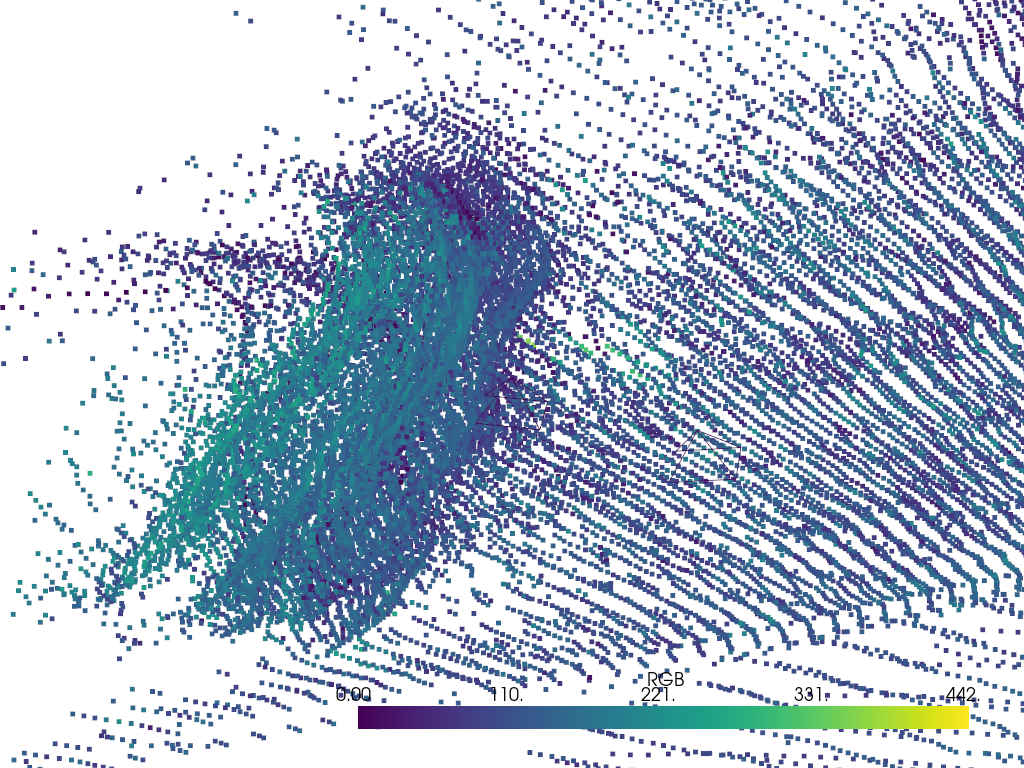

In [9]:
cloud_ma = pointcloud_to_polydata(pts3d_ma, RGB=colors_ma)
c2w_ma = [np.linalg.inv(ext) for ext in result_ma.extrinsics]
pl = visualize_splat(cloud_ma, aligned_cameras=c2w_ma)
pl.show()

## §7 — Side-by-side Comparison

Tabulates raw vs. filtered point counts and confidence statistics for both models. Higher confidence mean with lower std indicates more reliable depth predictions.

In [10]:
col = 14
print(f"{'Model':<{col}} {'Pts raw':>10} {'Pts filt':>10} {'Conf mean':>10} {'Conf std':>10}")
print("-" * (col + 42))
print(f"{'VGGT-X':<{col}} {len(result_vggt.pts3d):>10,} {len(pts3d_vggt):>10,} {conf_vggt_mean:>10.3f} {conf_vggt_std:>10.3f}")
print(f"{'MapAnything':<{col}} {len(result_ma.pts3d):>10,} {len(pts3d_ma):>10,} {conf_ma_mean:>10.3f} {conf_ma_std:>10.3f}")

Model             Pts raw   Pts filt  Conf mean   Conf std
--------------------------------------------------------
VGGT-X            500,000    187,484        nan        nan
MapAnything     4,414,774  4,212,983      0.214      0.224


## §8 — Camera Pose Overlay

Overlays camera frustums from both models in a single scene — blue for VGGT-X, orange for MapAnything. Alignment between the two sets indicates consistent global pose estimation.

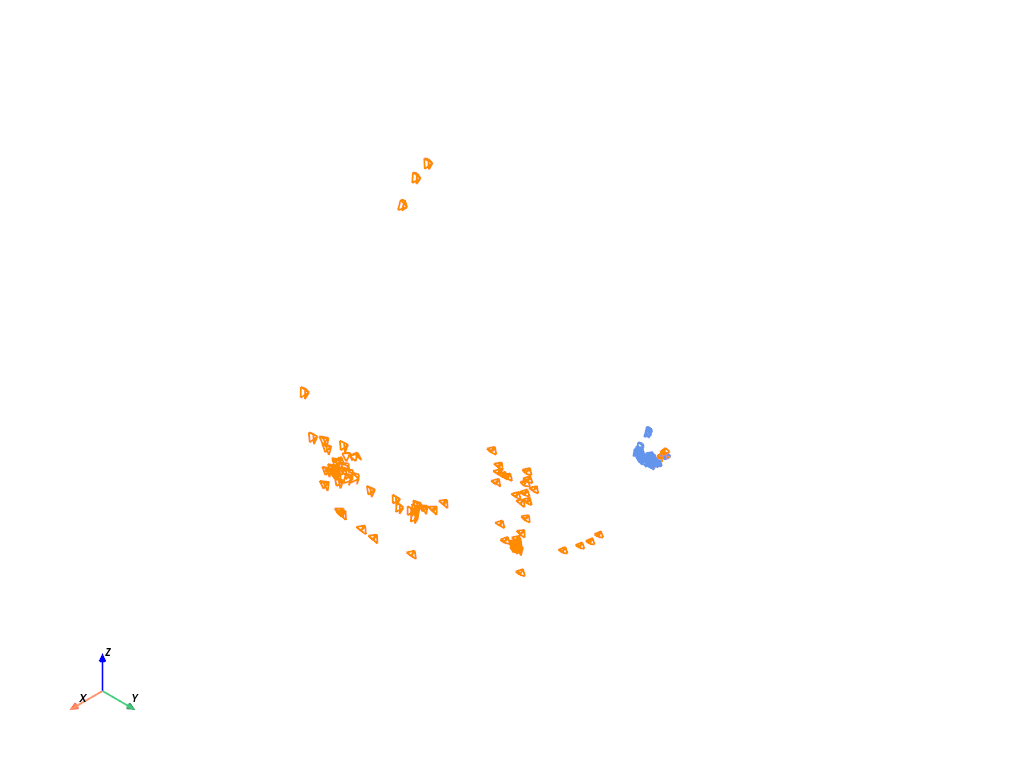

In [11]:
pl = pv.Plotter()
for ext in result_vggt.extrinsics:
    frustum = create_camera_frustum_pyvista(np.linalg.inv(ext), scale=0.05)
    pl.add_mesh(frustum, color="cornflowerblue", line_width=2)
for ext in result_ma.extrinsics:
    frustum = create_camera_frustum_pyvista(np.linalg.inv(ext), scale=0.05)
    pl.add_mesh(frustum, color="darkorange", line_width=2)
pl.add_axes()
pl.show()